In [ ]:
# instala o que precisa pra rodar o notebook
!pip install pandas numpy matplotlib scipy scikit-learn

In [1]:
# imports usados no notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [2]:
# carrega a planilha dos servidores
dados = pd.read_csv("servidores_ti.csv")
print(f"Dataset original: {dados.shape}")
dados.head()

Dataset original: (500, 7)


,servidor_id,tipo_rede,uso_cpu,uso_memoria,latencia_rede_ms,taxa_pacotes_perdidos,status_alerta
0,SRV-001,AWS,60.13,67.01,25.31,5.34,1
1,SRV-002,On-Premise,83.14,55.69,23.79,0.60,0
2,SRV-003,Azure,69.26,67.09,2.00,0.99,1
3,SRV-004,Azure,46.35,73.30,18.27,0.33,1
4,SRV-005,AWS,41.52,69.85,4.07,1.42,0


In [3]:
# dando uma olhada nos tipos de cada coluna
print(dados.dtypes)

servidor_id                  str
tipo_rede                    str
uso_cpu                  float64
uso_memoria              float64
latencia_rede_ms         float64
taxa_pacotes_perdidos    float64
status_alerta              int64
dtype: object


In [4]:
# média e variância amostral (s²) usando ddof=1, que é a versão não-viesada
cols = ["uso_cpu", "latencia_rede_ms"]
resumo = pd.DataFrame({
    "media": dados[cols].mean(),
    "variancia": dados[cols].var(ddof=1),
    "desvio_padrao": dados[cols].std(ddof=1),
    "n": dados[cols].count()
})
resumo

,media,variancia,desvio_padrao,n
uso_cpu,55.11006,227.791307,15.092757,500
latencia_rede_ms,24.91934,559.758393,23.659214,500


In [5]:
# intervalo de confiança de 95% pra média real de uso_cpu
# como não sabemos o desvio padrão da população, usamos a distribuição t de Student
# com (n-1) graus de liberdade
n = dados["uso_cpu"].count()
cpu_med = dados["uso_cpu"].mean()
cpu_dp = dados["uso_cpu"].std(ddof=1)
erro_pad = cpu_dp / np.sqrt(n)

conf = 0.95
alfa = 1 - conf
t_crit = stats.t.ppf(1 - alfa/2, df=n-1)
margem = t_crit * erro_pad

lim_inf = cpu_med - margem
lim_sup = cpu_med + margem

print(f"n = {n}")
print(f"Média amostral (X̄) = {cpu_med:.3f}%")
print(f"Desvio padrão amostral (s) = {cpu_dp:.3f}")
print(f"Erro padrão (s/√n) = {erro_pad:.4f}")
print(f"t crítico (gl={n-1}, 95%) = {t_crit:.4f}")
print(f"Margem de erro = {margem:.4f}")
print(f"IC 95% para a média de uso_cpu: [{lim_inf:.2f}% , {lim_sup:.2f}%]")

n = 500
Média amostral (X̄) = 55.110%
Desvio padrão amostral (s) = 15.093
Erro padrão (s/√n) = 0.6750
t crítico (gl=499, 95%) = 1.9647
Margem de erro = 1.3261
IC 95% para a média de uso_cpu: [53.78% , 56.44%]


parte 2

In [6]:
# tabela cruzada: tipo_rede x status_alerta
cruz = pd.crosstab(dados["tipo_rede"], dados["status_alerta"],
                    rownames=["tipo_rede"], colnames=["status_alerta"])
cruz.columns = ["Saudável (0)", "Falha Iminente (1)"]
cruz

,Saudável (0),Falha Iminente (1)
tipo_rede,,
AWS,169,38
Azure,133,29
On-Premise,106,25


In [7]:
# teste qui-quadrado de independência
qui2, p_val, gl, freq_esp = stats.chi2_contingency(cruz)

print(f"Estatística Qui-Quadrado (χ²) = {qui2:.4f}")
print(f"Graus de liberdade = {gl}")
print(f"p-valor = {p_val:.4f}")
print("\nFrequências esperadas sob H0 (independência):")
print(pd.DataFrame(freq_esp,
                    index=cruz.index,
                    columns=cruz.columns).round(2))

alfa = 0.05
if p_val < alfa:
    print(f"\nComo p-valor ({p_val:.4f}) < α ({alfa}), REJEITAMOS H0.")
else:
    print(f"\nComo p-valor ({p_val:.4f}) >= α ({alfa}), NÃO rejeitamos H0.")

Estatística Qui-Quadrado (χ²) = 0.0679
Graus de liberdade = 2
p-valor = 0.9666

Frequências esperadas sob H0 (independência):
            Saudável (0)  Falha Iminente (1)
tipo_rede                                   
AWS               168.91               38.09
Azure             132.19               29.81
On-Premise        106.90               24.10

Como p-valor (0.9666) >= α (0.05), NÃO rejeitamos H0.


parte 3

In [8]:
# separa as colunas numéricas e padroniza pra deixar tudo na mesma escala
cols_num = ["uso_cpu", "uso_memoria", "latencia_rede_ms", "taxa_pacotes_perdidos"]
vals = dados[cols_num].values

norm = StandardScaler()
vals_pad = norm.fit_transform(vals)

print("Média após padronização (deve ser ~0):", vals_pad.mean(axis=0).round(3))
print("Desvio padrão após padronização (deve ser ~1):", vals_pad.std(axis=0).round(3))

Média após padronização (deve ser ~0): [ 0.  0. -0.  0.]
Desvio padrão após padronização (deve ser ~1): [1. 1. 1. 1.]


In [9]:
# PCA com 2 componentes principais
pca = PCA(n_components=2)
comp = pca.fit_transform(vals_pad)

tab_pca = pd.DataFrame(comp, columns=["PC1", "PC2"])
tab_pca["status_alerta"] = dados["status_alerta"].values

var_exp = pca.explained_variance_ratio_
var_ac = np.cumsum(var_exp)

print("Variância explicada por componente:")
for i, (v, vac) in enumerate(zip(var_exp, var_ac), start=1):
    print(f"  PC{i}: {v*100:.2f}% (acumulada: {vac*100:.2f}%)")

Variância explicada por componente:
  PC1: 26.58% (acumulada: 26.58%)
  PC2: 26.02% (acumulada: 52.60%)


In [10]:
# cargas fatoriais: o quanto cada variável original pesa em PC1 e PC2
cargas = pd.DataFrame(pca.components_, columns=cols_num, index=["PC1", "PC2"])
cargas.round(3)

,uso_cpu,uso_memoria,latencia_rede_ms,taxa_pacotes_perdidos
PC1,-0.097,0.261,0.700,-0.658
PC2,0.704,0.660,0.084,0.248


parte 4

In [11]:
# X (componentes principais) e y (alvo)
X = tab_pca[["PC1", "PC2"]].values
y = tab_pca["status_alerta"].values

# separa treino (70%) e teste (30%), com semente fixa pra dar pra reproduzir
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Tamanho do treino: {X_tr.shape[0]} amostras")
print(f"Tamanho do teste:  {X_te.shape[0]} amostras")
print(f"Proporção de falhas (classe 1) no treino: {y_tr.mean()*100:.1f}%")
print(f"Proporção de falhas (classe 1) no teste:  {y_te.mean()*100:.1f}%")

Tamanho do treino: 350 amostras
Tamanho do teste:  150 amostras
Proporção de falhas (classe 1) no treino: 18.3%
Proporção de falhas (classe 1) no teste:  18.7%


In [12]:
# treina o classificador KNN com K = 5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_tr, y_tr)

y_prev = knn.predict(X_te)

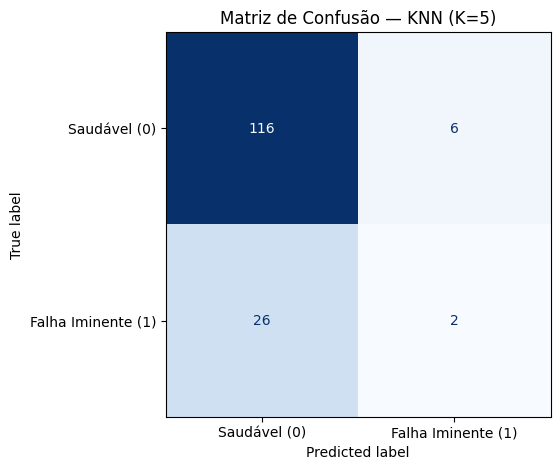

[[116   6]
 [ 26   2]]


In [13]:
# matriz de confusão
matriz = confusion_matrix(y_te, y_prev)

fig, ax = plt.subplots(figsize=(5.5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=matriz,
                               display_labels=["Saudável (0)", "Falha Iminente (1)"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de Confusão — KNN (K=5)")
plt.tight_layout()
plt.show()

print(matriz)

In [14]:
# relatório completo de classificação (precisão, revocação, F1-score)
relat = classification_report(y_te, y_prev,
                               target_names=["Saudável (0)", "Falha Iminente (1)"],
                               digits=3)
print(relat)

                    precision    recall  f1-score   support

      Saudável (0)      0.817     0.951     0.879       122
Falha Iminente (1)      0.250     0.071     0.111        28

          accuracy                          0.787       150
         macro avg      0.533     0.511     0.495       150
      weighted avg      0.711     0.787     0.735       150

